# Evaluate SAR runoff onset against snow pillow stations

Mirrors `../compare_to_NorSWE/3_evaluate_NorSWE.ipynb`. Applies the filter regime chosen in `2_compare_snow_pillows.ipynb`, aggregates to per-station-water-year medians, and produces the evaluation figures (per-year residual histograms + spatial bias map).

In [1]:
import xarray as xr
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from pathlib import Path
import numpy as np
import os
import seaborn as sns
import rioxarray as rxr
from shapely.geometry import box

In [2]:
# Dataset version being analysed -- must match the config used in notebook 1. Inputs
# and figures are both version-scoped, so v9 and v10 products never overwrite each other.
VERSION = 'v10'

COMPARISON_DATA_DIR = Path('data/comparison_datasets') / VERSION
MAX_SWE_TIMING_OUTPUT_ZARR_FILEPATH = COMPARISON_DATA_DIR / 'max_snow_pillow_swe_timing.zarr'
RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH = COMPARISON_DATA_DIR / 'runoff_onset_snow_pillow_station_chips.zarr'

FIGURE_DIR = Path('figures') / VERSION
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PCT = 95  # SWE threshold percentile to compare against (e.g. 50, 90, 95, 99, 100)

In [3]:
max_swe_timing_ds = xr.open_zarr(MAX_SWE_TIMING_OUTPUT_ZARR_FILEPATH)
runoff_onset_chips_ds = xr.open_zarr(RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH)
runoff_onset_chips_ds['radius'] = np.sqrt(
    runoff_onset_chips_ds['x_rel']**2 + runoff_onset_chips_ds['y_rel']**2
)

In [4]:
# Only load variables needed for this figure
snow_pillow_ds = xr.merge([
    runoff_onset_chips_ds[['runoff_onset', 'fcf', 'temporal_resolution', 'worldcover', 'snow_class', 'radius']],
    max_swe_timing_ds[['100pct_of_max_SWE_timing', '99pct_of_max_SWE_timing', '95pct_of_max_SWE_timing', '90pct_of_max_SWE_timing', '50pct_of_max_SWE_timing', 'max_SWE_value']],
], join='inner')

snow_pillow_ds['sar_minus_100pct'] = snow_pillow_ds['runoff_onset'] - snow_pillow_ds['100pct_of_max_SWE_timing']
snow_pillow_ds['sar_minus_99pct'] = snow_pillow_ds['runoff_onset'] - snow_pillow_ds['99pct_of_max_SWE_timing']
snow_pillow_ds['sar_minus_95pct'] = snow_pillow_ds['runoff_onset'] - snow_pillow_ds['95pct_of_max_SWE_timing']
snow_pillow_ds['sar_minus_90pct'] = snow_pillow_ds['runoff_onset'] - snow_pillow_ds['90pct_of_max_SWE_timing']
snow_pillow_ds['sar_minus_50pct'] = snow_pillow_ds['runoff_onset'] - snow_pillow_ds['50pct_of_max_SWE_timing']

snow_pillow_ds

<xarray.Dataset> Size: 423MB
Dimensions:                   (station_id: 1233, water_year: 11, x_rel: 25,
                               y_rel: 25)
Coordinates: (12/16)
  * station_id                (station_id) <U16 79kB '05BL812_AB_MSNT' ... 'WTM'
    band                      (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_epsg          (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_x             (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_y             (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    time                      (station_id) datetime64[ns] 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    ...                        ...
    network                   (station_id) <U5 25kB dask.array<chunksize=(1233,), meta=np.ndarray>
    state                     (station_id) <U2 10kB dask.array<chunksize=(1233,), meta=np.ndarray>
    station_name              (station_id) <U41 202kB dask.array<chunksize=(1233,), meta=np.ndarray>
  * water_year                (water_year) int64 88B 2015 2016 ... 2024 2025
  * x_rel                     (x_rel) int64 200B -960 -880 -800 ... 800 880 960
  * y_rel                     (y_rel) int64 200B -960 -880 -800 ... 800 880 960
Data variables: (12/17)
    runoff_onset              (station_id, water_year, y_rel, x_rel) float32 34MB dask.array<chunksize=(30, 11, 25, 25), meta=np.ndarray>
    fcf                       (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    temporal_resolution       (station_id, water_year, y_rel, x_rel) float32 34MB dask.array<chunksize=(30, 11, 25, 25), meta=np.ndarray>
    worldcover                (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    snow_class                (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    radius                    (x_rel, y_rel) float64 5kB 1.358e+03 ... 1.358e+03
    ...                        ...
    max_SWE_value             (water_year, station_id) float32 54kB dask.array<chunksize=(11, 1233), meta=np.ndarray>
    sar_minus_100pct          (station_id, water_year, y_rel, x_rel) float64 68MB dask.array<chunksize=(30, 11, 25, 25), meta=np.ndarray>
    sar_minus_99pct           (station_id, water_year, y_rel, x_rel) float64 68MB dask.array<chunksize=(30, 11, 25, 25), meta=np.ndarray>
    sar_minus_95pct           (station_id, water_year, y_rel, x_rel) float64 68MB dask.array<chunksize=(30, 11, 25, 25), meta=np.ndarray>
    sar_minus_90pct           (station_id, water_year, y_rel, x_rel) float64 68MB dask.array<chunksize=(30, 11, 25, 25), meta=np.ndarray>
    sar_minus_50pct           (station_id, water_year, y_rel, x_rel) float64 68MB dask.array<chunksize=(30, 11, 25, 25), meta=np.ndarray>

In [5]:
# station counts per network
pd.Series(snow_pillow_ds['network'].values).value_counts()

SNTL    856
CCSS    134
MSNT    110
BCSS    107
NVE      19
YSS       7
Name: count, dtype: int64

In [6]:
# Compute boolean filter mask once
fcf_lte = 50
exclude_worldcover = [50, 80]  # builtup, water
max_swe_gte = 200  # mm
temp_res_lte = 14
radius_lte = 1000
valid_cnt = 1  # minimum number of valid pixels per station to include in median

mask = (
    (snow_pillow_ds['fcf'] <= fcf_lte) &
    (~snow_pillow_ds['worldcover'].isin(exclude_worldcover)) &
    (snow_pillow_ds['max_SWE_value'] >= max_swe_gte) &
    (snow_pillow_ds['temporal_resolution'] <= temp_res_lte) &
    (snow_pillow_ds['radius'] <= radius_lte)
)

exclude_worldcover_str = '_'.join(str(x) for x in exclude_worldcover)
filter_string = f'fcf_lte_{fcf_lte}_exclude_worldcover_{exclude_worldcover_str}_max_swe_gte_{max_swe_gte}_temp_res_lte_{temp_res_lte}_radius_lte_{radius_lte}_valid_cnt_{valid_cnt}'

# Aggregate one variable at a time to minimize peak memory
def masked_median(var):
    return snow_pillow_ds[var].where(mask).median(dim=['x_rel', 'y_rel'])

pct_var = f'{PCT}pct_of_max_SWE_timing'
diff_var = f'sar_minus_{PCT}pct'

sar_filtered = snow_pillow_ds[diff_var].where(mask)
sar_median = sar_filtered.median(dim=['x_rel', 'y_rel'])
sar_count = sar_filtered.count(dim=['x_rel', 'y_rel'])

runoff_median   = masked_median('runoff_onset')
timing_median   = masked_median(pct_var)
tempres_median  = masked_median('temporal_resolution')

valid = sar_count > valid_cnt
median_per_station_water_year_with_mincnt_ds = xr.Dataset({
    f'sar_minus_station_{PCT}pct_timing': sar_median.where(valid),
    'runoff_onset':                       runoff_median.where(valid),
    pct_var:                              timing_median.where(valid),
    'temporal_resolution':                tempres_median.where(valid),
}).dropna('station_id', how='all')

sar_minus_pct_timing_da = sar_median.where(valid).dropna('station_id', how='all')

/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/def

In [7]:
n_sy = int(sar_minus_pct_timing_da.notnull().sum())
n_st = int(sar_minus_pct_timing_da.notnull().any(dim='water_year').sum())
print(f"***{n_sy:,} water-year observations with valid runoff onset estimates across {n_st:,} stations***")

/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


***8,397 water-year observations with valid runoff onset estimates across 1,135 stations***


In [8]:
station_bias_da  = sar_minus_pct_timing_da.median(dim='water_year')
station_bias_df  = station_bias_da.to_dataframe(name='bias').reset_index()
station_bias_gdf = gpd.GeoDataFrame(
    station_bias_df,
    geometry=gpd.points_from_xy(station_bias_df.longitude, station_bias_df.latitude),
    crs='EPSG:4326',
)

/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [9]:
STATION_VAR = pct_var
OUR_VAR     = 'runoff_onset'
med_ds      = median_per_station_water_year_with_mincnt_ds

df_sar = (med_ds[[OUR_VAR, 'temporal_resolution']].to_dataframe()
          .reset_index().dropna(subset=[OUR_VAR])
          .rename(columns={OUR_VAR: 'Value'})
          .assign(**{'Derived from': 'our product'}))
df_station = (med_ds[[STATION_VAR]].to_dataframe()
              .reset_index().dropna(subset=[STATION_VAR])
              .rename(columns={STATION_VAR: 'Value'})
              .assign(**{'Derived from': 'snow pillow'}))
df_combined = pd.concat([df_sar, df_station])[['water_year', 'Value', 'Derived from']]

df_residuals = (sar_minus_pct_timing_da
                .to_dataframe(name='residual').reset_index().dropna(subset=['residual']))

water_years = sorted(df_combined['water_year'].unique())
temp_res_per_wy = [
    float(med_ds['temporal_resolution'].sel(water_year=wy).mean().values)
    for wy in water_years
]

/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/def

In [10]:
# bulk stats: median, MAD, n, mean temporal resolution
print(f"With the following filters...\n{filter_string}")
print(f"Residuals count: {len(df_residuals)}")
print(f"Residuals median: {df_residuals['residual'].median()}")
print(f"Residuals MAD: {np.median(np.abs(df_residuals['residual'] - df_residuals['residual'].median()))}")
print(f"Mean temporal res: {df_sar['temporal_resolution'].mean()}")

With the following filters...
fcf_lte_50_exclude_worldcover_50_80_max_swe_gte_200_temp_res_lte_14_radius_lte_1000_valid_cnt_1
Residuals count: 8397
Residuals median: -2.0
Residuals MAD: 10.0
Mean temporal res: 6.867774486541748


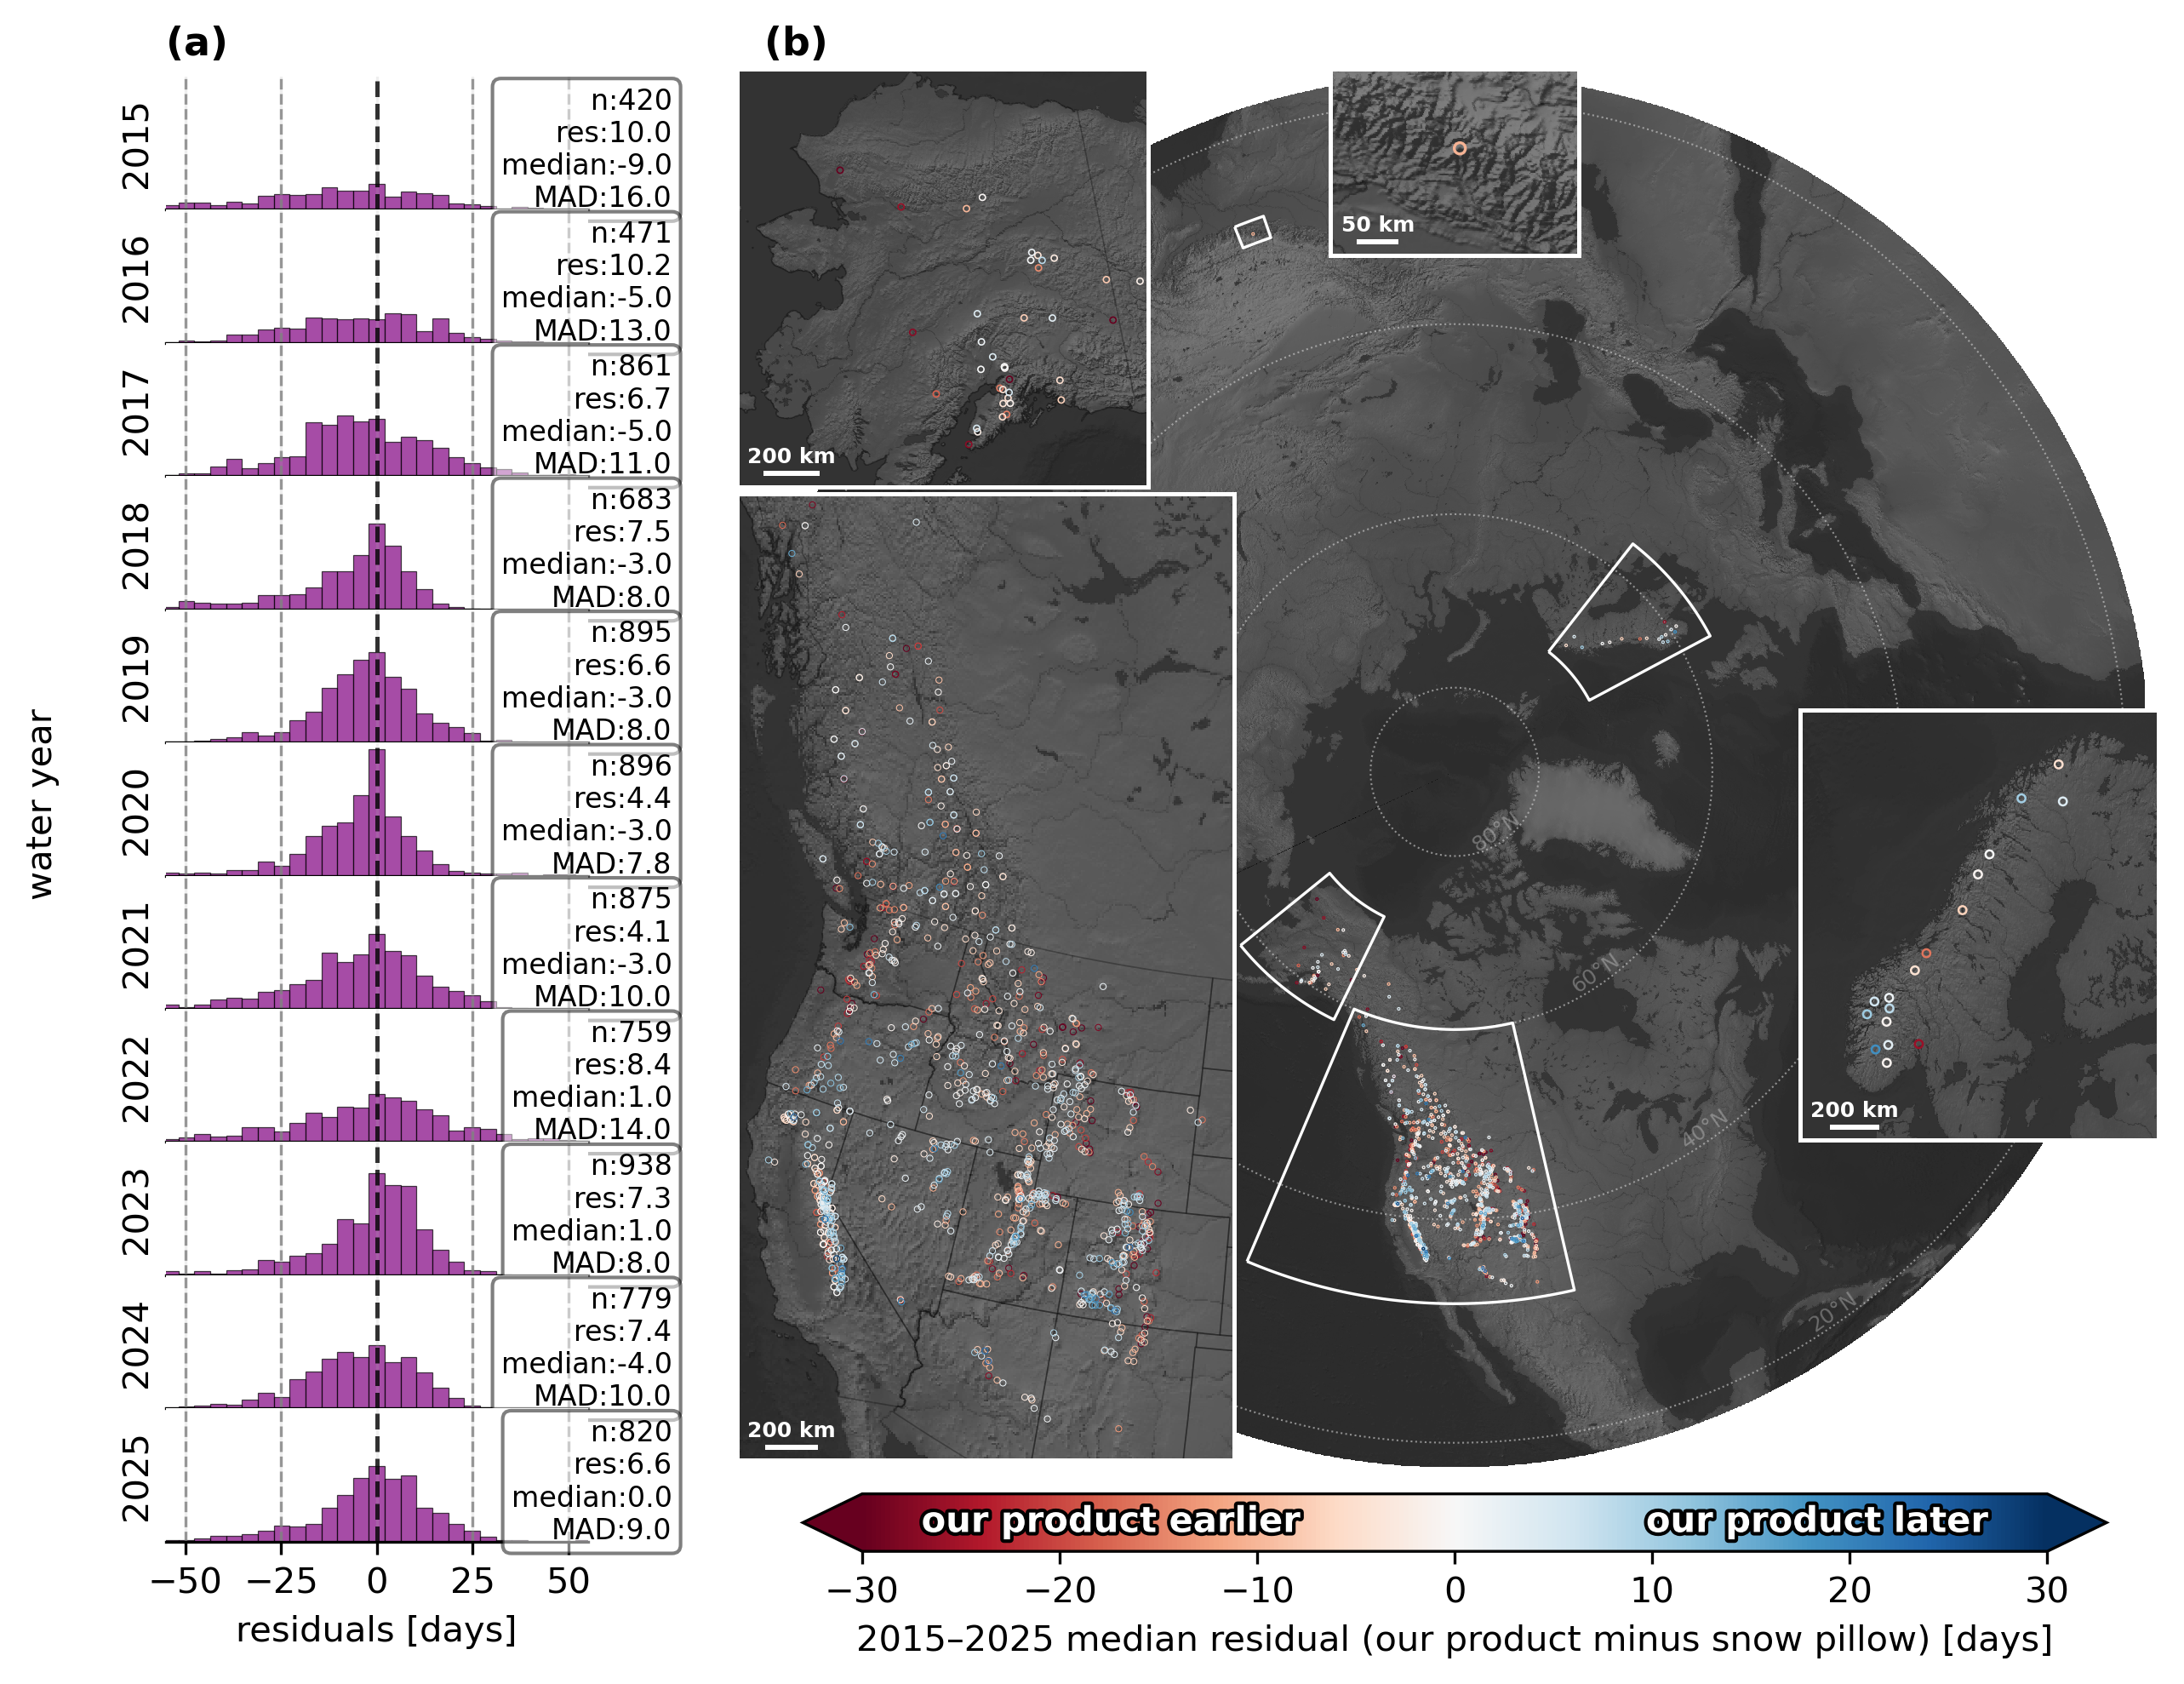

In [15]:
# no-violin figure with three equal-area regional zoom insets over the polar map
# (rotated polar stereographic, lon_0=-90). White outlines mark each inset's source region.
# Refactored into make_regional_insets_figure() so the same layout can be rendered for
# all stations, for the WUS only, and for the non-WUS (Alaska/BC/Norway/Nepal) subset.
from shapely.geometry import box, LineString, Point
from matplotlib_scalebar.scalebar import ScaleBar

# US state polygons: used both for inset boundaries and for WUS/non-WUS station classification
states_gdf = gpd.read_file('http://eric.clst.org/assets/wiki/uploads/Stuff/gz_2010_us_040_00_5m.json')

# --- full set of regional insets over the polar map: equal-area zooms ---
# The regional figures below pass a subset of this dict (the inset placements are hand-tuned
# per region, so subsetting simply drops insets and leaves the rest where they are).
ALL_REGIONS = {
    'Western North America': dict(bbox=[-138, 32, -102, 60], s=3, lw=0.25,
                                  inset=[-0.02, 0.005, 0.36, 0.72], anchor='SW',
                                  proj_lon0=-95, extent='stations', margin_km=120),
    'Alaska':                dict(bbox=[-166, 58, -141, 71], s=3, lw=0.4,
                                  inset=[-0.02, 0.705, 0.34, 0.30], anchor='SW',
                                  margin_km=120),
    'Norway':                dict(bbox=[3, 56.5, 27, 72], s=5, lw=0.6,
                                  inset=[0.75, 0.17, 0.26, 0.44], anchor='E'), #.28
    'Nepal':                 dict(bbox=[84, 27, 87, 29], s=10, lw=0.8,
                                  inset=[0.41, 0.855, 0.18, 0.15], anchor='NW'),
}

PAD_LON, PAD_LAT = 12, 6   # extra hillshade context so the rectangular frame is fully filled
SCALEBAR_THICKNESS_IN = 0.02  # absolute bar thickness on the figure, same for every inset

def region_aea_proj(bbox, lon0=None):
    """Albers equal-area projection centered on the region, standard parallels at 1/6 in.

    lon0 east of the region rotates it clockwise in the projection - used to make the
    NW-SE trending WNA station band vertical so it fits a tall, skinny inset."""
    lon1, lat1, lon2, lat2 = bbox
    lat_span = lat2 - lat1
    if lon0 is None:
        lon0 = (lon1 + lon2) / 2
    return (f"+proj=aea +lon_0={lon0} +lat_0={(lat1 + lat2) / 2} "
            f"+lat_1={lat1 + lat_span / 6} +lat_2={lat2 - lat_span / 6} "
            f"+datum=WGS84 +units=m +no_defs")

def bbox_ring(bbox, n=100):
    """Densified lon/lat outline of a bbox (projects to a curved shape in conic/polar CRS)."""
    lon1, lat1, lon2, lat2 = bbox
    lons = np.linspace(lon1, lon2, n)
    lats = np.linspace(lat1, lat2, n)
    return LineString([(x, lat1) for x in lons] + [(lon2, y) for y in lats]
                      + [(x, lat2) for x in lons[::-1]] + [(lon1, y) for y in lats[::-1]])


def make_regional_insets_figure(df_res, station_gdf, regions, temp_res_per_wy, save_suffix=''):
    """Per-year residual histograms + polar bias map with regional equal-area zoom insets.

    df_res / station_gdf are the (optionally geographically subset) residual and per-station
    bias tables; regions selects which insets to draw; save_suffix is appended to the filename.
    """
    # global y-scale for the histogram column, from this subset's residuals
    bins = np.linspace(-60, 60, 30)
    max_count = 0
    for wy in water_years:
        year_data = df_res[df_res['water_year'] == wy]['residual']
        counts, _ = np.histogram(year_data, bins=bins)
        max_count = max(max_count, counts.max())
    global_y_max = max_count * 1.05   # pad so the tallest bar doesn't touch the top spine

    # --- Figure layout ---
    n_years = len(water_years)
    fig = plt.figure(figsize=(10, 7.5), dpi=300)
    gs = fig.add_gridspec(n_years, 3, width_ratios=[1.1, 0.2, 3.6],
                          height_ratios=[1] * n_years, hspace=0.00, wspace=0.08)

    # --- Left panels: per-year residual histograms ---
    hist_axes = []
    for i, wy in enumerate(water_years):
        ax = fig.add_subplot(gs[i, 0], zorder=i + 1)
        hist_axes.append(ax)
        year_data = df_res[df_res['water_year'] == wy]['residual']

        ax.hist(year_data, bins=bins, alpha=0.7, color='purple',
                edgecolor='black', linewidth=0.3, orientation='vertical')
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
        ax.grid(True, alpha=0.2)

        ax.set_ylim([0, global_y_max])

        median_val = float(year_data.median()) if len(year_data) else np.nan
        mad_val    = float(np.median(np.abs(year_data - median_val))) if len(year_data) else np.nan
        n_samples  = len(year_data)
        tres       = temp_res_per_wy[i]

        ax.text(1.2, 0.92, f"n:{n_samples}\nres:{tres:.1f}\nmedian:{median_val:.1f}\nMAD:{mad_val:.1f}",
                transform=ax.transAxes, verticalalignment='top', horizontalalignment='right',
                fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor='black'))

        ax.set_xlim([-55, 55])
        ax.set_xticks([-50, -25, 0, 25, 50])
        ax.set_yticks([])
        if i == n_years - 1:
            ax.set_xlabel('residuals [days]')
        else:
            ax.set_xticklabels([])
        ax.set_ylabel(f'{wy}', rotation=90, ha='center', va='center', labelpad=8, fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        for x_loc in [-50, -25, 25, 50]:
            ax.axvline(x=x_loc, linestyle='--', color='gray', linewidth=0.8, alpha=0.8)

    fig.supylabel('water year', x=0.07, fontsize=10)
    hist_axes[0].set_title('(a)', loc='left', fontsize=11, fontweight='bold')

    # --- Right panel: spatial bias map (polar view) ---
    ax_map = fig.add_subplot(gs[:, -1])

    # polar stereographic like EPSG:3995 but rotated 90 deg counter-clockwise (lon_0=-90)
    target_crs = "+proj=stere +lat_0=90 +lat_ts=71 +lon_0=-115 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    gdf_proj = station_gdf.to_crs(target_crs)

    NH_box = [-180, 18, 180, 90]

    hillshade_da = (rxr.open_rasterio('../../visualize/data/global_hillshade_robinson.tif',
                                       masked=True, chunks='auto')
                    .squeeze()
                    .rio.clip_box(*NH_box, crs='EPSG:4326').coarsen(x=10, y=10, boundary='trim').mean()
                    .rio.reproject(target_crs))
    hillshade_da.plot.imshow(cmap='grey', ax=ax_map, vmin=0, vmax=500,
                             zorder=0, alpha=1, add_colorbar=False)

    hillshade_bounds_gdf = gpd.GeoDataFrame(geometry=[box(*hillshade_da.rio.bounds())], crs=target_crs)

    cmap_map = cm.RdBu
    norm_map = Normalize(vmin=-30, vmax=30)
    gdf_sorted = gdf_proj.sort_values('bias', ascending=True)
    ax_map.scatter(
        gdf_sorted.geometry.x, gdf_sorted.geometry.y,
        s=0.5,
        edgecolors=cmap_map(norm_map(gdf_sorted['bias'].values)),
        facecolors='none',
        linewidths=0.3,
        zorder=2,
    )

    ax_map.set_aspect('equal')
    # hug the top of the gridspec cell so (b) sits tight over the map, aligned with (a)
    ax_map.set_anchor('N')
    ax_map.axis('off')
    ax_map.set_title('')   # clear xarray's auto center title
    # pin y=1.0: auto-positioning floats the title above the overlaid insets
    ax_map.set_title('(b)', loc='left', fontsize=11, fontweight='bold', y=1.0)

    # Colorbar overlaid on bottom row of map column
    ax_cbar = fig.add_subplot(gs[-1, -1])
    sm = cm.ScalarMappable(cmap=cmap_map, norm=norm_map)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=ax_cbar, extend='both', orientation='horizontal')
    pos = ax_cbar.get_position()
    ax_cbar.set_position([pos.x0 + 0.015, pos.y0 - 0.00, pos.width - 0.03, pos.height - 0.04])
    cbar.set_label(f'{water_years[0]}–{water_years[-1]} median residual (our product minus snow pillow) [days]')

    earlier = cbar.ax.text(0.05, 0.5, 'our product earlier', transform=cbar.ax.transAxes,
                           fontsize=10, color='white', weight='bold', ha='left', va='center')
    later   = cbar.ax.text(0.95, 0.5, 'our product later',   transform=cbar.ax.transAxes,
                           fontsize=10, color='white', weight='bold', ha='right', va='center')
    earlier.set_path_effects([matplotlib.patheffects.withStroke(linewidth=2, foreground='black')])
    later.set_path_effects([  matplotlib.patheffects.withStroke(linewidth=2, foreground='black')])

    # stretch the histogram column down so its x-label lines up with the colorbar label
    hist_top = hist_axes[0].get_position().y1
    hist_bottom = ax_cbar.get_position().y0 + 0.005
    row_h = (hist_top - hist_bottom) / n_years
    for k, hax in enumerate(hist_axes):
        p = hax.get_position()
        hax.set_position([p.x0, hist_top - (k + 1) * row_h, p.width, row_h])

    # latitude circles
    target_latitudes = [80, 60, 40, 20]
    lons = np.linspace(-180, 180, 361)
    lat_lines_gdf = gpd.GeoDataFrame(
        {'latitude': target_latitudes},
        geometry=[LineString([(lon, lat) for lon in lons]) for lat in target_latitudes],
        crs='EPSG:4326',
    ).to_crs(target_crs)
    lat_lines_gdf = gpd.clip(lat_lines_gdf, hillshade_bounds_gdf)
    lat_lines_gdf.plot(ax=ax_map, color='lightgray', linewidth=0.5, linestyle=':', alpha=0.6, zorder=1)

    label_angle_deg = -55
    theta = np.deg2rad(label_angle_deg)
    pole_xy = gpd.GeoSeries([Point(0, 90)], crs='EPSG:4326').to_crs(target_crs).iloc[0]
    pole_x, pole_y = pole_xy.x, pole_xy.y
    label_offset = -150_000
    for _, row in lat_lines_gdf.iterrows():
        coords = np.array(row.geometry.coords)
        angles = np.arctan2(coords[:, 1] - pole_y, coords[:, 0] - pole_x)
        angle_diff = np.angle(np.exp(1j * (angles - theta)))
        idx = np.argmin(np.abs(angle_diff))
        x_lab, y_lab = coords[idx]
        x_lab += label_offset * np.cos(theta)
        y_lab += label_offset * np.sin(theta)
        ax_map.text(x_lab, y_lab, f"{int(row['latitude'])}°N",
                    fontsize=6, color='white', alpha=0.3, ha='center', va='center',
                    rotation=label_angle_deg + 90, rotation_mode='anchor', zorder=1)

    # --- regional insets (equal-area) + source boxes on the polar map ---
    inset_axes_list = []
    for region, cfg in regions.items():
        bbox = cfg['bbox']
        aea = region_aea_proj(bbox, lon0=cfg.get('proj_lon0'))
        ring = bbox_ring(bbox)

        if region == 'Nepal':
            INSET_COARSEN = 1
        if region == 'Alaska':
            INSET_COARSEN = 3
        if region == 'Western North America':
            INSET_COARSEN = 6
        if region == 'Norway':
            INSET_COARSEN = 4

        # outline the source region on the polar map (may extend beyond the inset's bbox)
        outline_ring = bbox_ring(cfg.get('outline_bbox', bbox))
        gpd.GeoSeries([outline_ring], crs='EPSG:4326').to_crs(target_crs).plot(
            ax=ax_map, color='white', linewidth=0.8, linestyle='-', zorder=3)

        ax_in = ax_map.inset_axes(cfg['inset'], zorder=12)
        inset_axes_list.append(ax_in)
        # ocean-toned background: any corner the padded clip can't reach (e.g. beyond the
        # antimeridian) blends in instead of showing white
        ax_in.set_facecolor((0.37, 0.37, 0.37))

        # clip well beyond the bbox so the rectangular display extent is fully covered
        pad_bbox = [max(bbox[0] - PAD_LON, -180), max(bbox[1] - PAD_LAT, -90),
                    min(bbox[2] + PAD_LON, 180), min(bbox[3] + PAD_LAT, 90)]
        hs = (rxr.open_rasterio('../../visualize/data/global_hillshade_robinson.tif',
                                masked=True, chunks='auto')
              .squeeze()
              .rio.clip_box(*pad_bbox, crs='EPSG:4326')
              .coarsen(x=INSET_COARSEN, y=INSET_COARSEN, boundary='trim').mean()
              .rio.reproject(aea))
        hs.plot.imshow(cmap='grey', ax=ax_in, vmin=0, vmax=500, zorder=0, add_colorbar=False)

        if region in ('Western North America', 'Alaska'):
            states_gdf.to_crs(aea).boundary.plot(ax=ax_in, edgecolor='black', linewidth=0.4,
                                                 zorder=1, alpha=0.3)

        # include stations from the padded area too, so no visible gaps inside the rectangle
        in_box = station_gdf.cx[pad_bbox[0]:pad_bbox[2], pad_bbox[1]:pad_bbox[3]]
        in_box_proj = in_box.to_crs(aea).sort_values('bias', ascending=True)
        ax_in.scatter(in_box_proj.geometry.x, in_box_proj.geometry.y,
                      s=cfg['s'], edgecolors=cmap_map(norm_map(in_box_proj['bias'].values)),
                      facecolors='none', linewidths=cfg['lw'], zorder=2)

        if cfg.get('extent') == 'stations':
            # tight rectangular extent around the region's stations (trims open ocean)
            st = station_gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]].to_crs(aea)
            m = cfg.get('margin_km', 120) * 1000
            xmin, xmax = st.geometry.x.min() - m, st.geometry.x.max() + m
            ymin, ymax = st.geometry.y.min() - m, st.geometry.y.max() + m
        else:
            # rectangular display extent circumscribing the projected bbox (curved edges cropped)
            xmin, ymin, xmax, ymax = gpd.GeoSeries([ring], crs='EPSG:4326').to_crs(aea).total_bounds
            xs = cfg.get('xshrink', (0.0, 0.0))
            xs = (xs, xs) if np.isscalar(xs) else xs
            xmin, xmax = xmin + xs[0] * (xmax - xmin), xmax - xs[1] * (xmax - xmin)
        ax_in.set_xlim([xmin, xmax])
        ax_in.set_ylim([ymin, ymax])
        ax_in.set_aspect('equal')
        ax_in.set_anchor(cfg.get('anchor', 'C'))
        ax_in.set_title('')
        ax_in.set_xlabel(''); ax_in.set_ylabel('')
        ax_in.set_xticks([]); ax_in.set_yticks([])
        for spine in ax_in.spines.values():
            spine.set_edgecolor('white')
            spine.set_linewidth(1.2)

    # scale bars: same absolute thickness on the figure for every inset. width_fraction is
    # relative to each axes' height, and aspect='equal' shrinks each inset's drawn box by a
    # different amount, so lay out the figure first and measure the final heights.
    fig.canvas.draw()
    for ax_in in inset_axes_list:
        ax_height_in = ax_in.get_window_extent().height / fig.dpi
        ax_in.add_artist(ScaleBar(1, units='m', location='lower left', box_alpha=0.0,
                                  font_properties={'size': 6, 'weight': 'bold'}, color='white',
                                  length_fraction=0.25, frameon=False,
                                  width_fraction=SCALEBAR_THICKNESS_IN / ax_height_in,
                                  scale_loc='top', sep=1))

    fig.savefig(FIGURE_DIR / (f'snow_pillow_evaluation_SAR_minus_{PCT}pct_of_max_SWE_timing_{filter_string}'
                              f'_no_violin_regional_insets{save_suffix}.png'),
                bbox_inches='tight', dpi=300)


# --- helpers for the WUS / non-WUS subsets below ---
# contiguous US = all states except Alaska; a station is "WUS" if it falls inside that polygon
_wus_union = states_gdf[~states_gdf['NAME'].isin(['Alaska'])].to_crs('EPSG:4326').union_all()



def wus_mask(df):
    """Boolean mask (per row) of df with longitude/latitude columns inside the contiguous US."""
    pts = gpd.GeoSeries(gpd.points_from_xy(df['longitude'], df['latitude']), crs='EPSG:4326')
    return pts.within(_wus_union).to_numpy()

def temp_res_for(df_res):
    """Mean temporal resolution per water year for the stations present in df_res."""
    sids = df_res['station_id'].unique()
    sub = median_per_station_water_year_with_mincnt_ds['temporal_resolution'].sel(station_id=sids)
    return [float(sub.sel(water_year=wy).mean().values) for wy in water_years]


# --- all stations (original figure) ---
make_regional_insets_figure(df_residuals, station_bias_gdf, ALL_REGIONS, temp_res_per_wy, save_suffix='')

WUS: 931 stations, 7242 station-water-years


/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/def

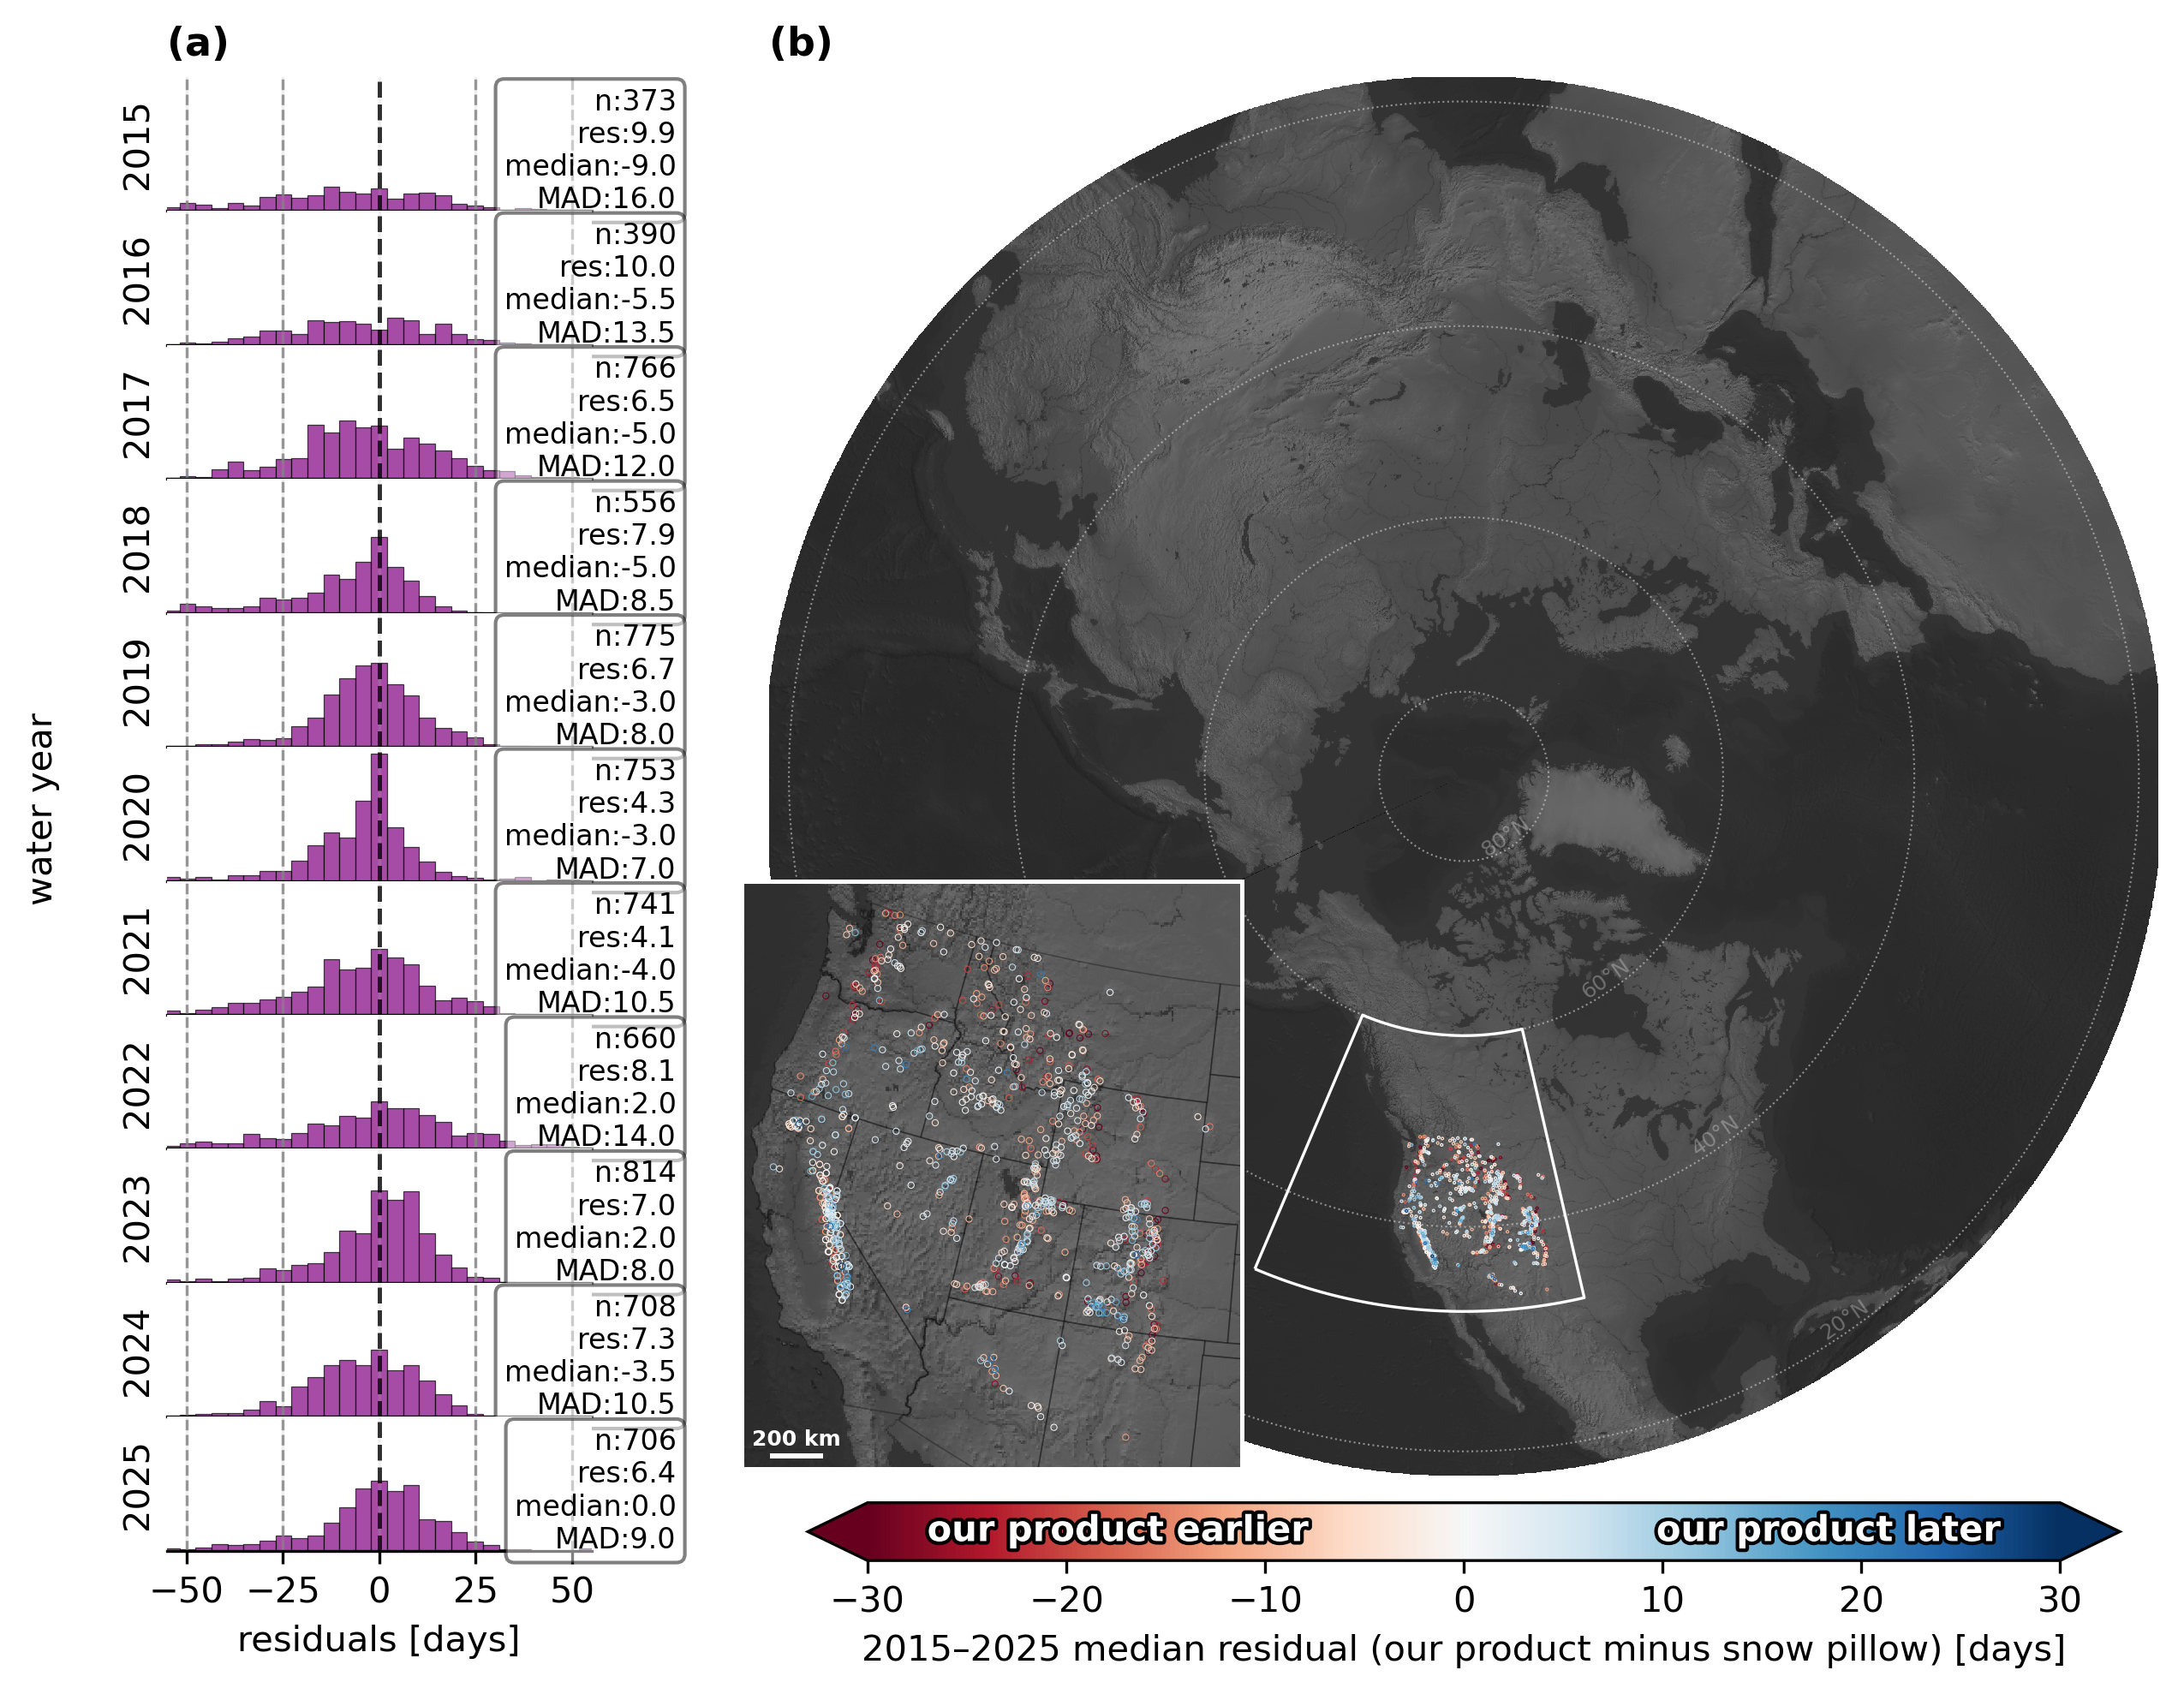

In [16]:
# WUS version: contiguous Western U.S. stations only (excludes Alaska)
# Same layout as above, restricted to stations inside the contiguous US and showing only
# the Western North America inset.
_wus_bias  = wus_mask(station_bias_gdf)
_wus_res   = wus_mask(df_residuals)
station_bias_gdf_WUS = station_bias_gdf[_wus_bias]
df_residuals_WUS     = df_residuals[_wus_res]
print(f"WUS: {station_bias_gdf_WUS['station_id'].nunique()} stations, {len(df_residuals_WUS)} station-water-years")

make_regional_insets_figure(
    df_residuals_WUS,
    station_bias_gdf_WUS,
    {k: ALL_REGIONS[k] for k in ['Western North America']},
    temp_res_for(df_residuals_WUS),
    save_suffix='_WUS',
)

non-WUS: 204 stations, 1155 station-water-years


/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/def

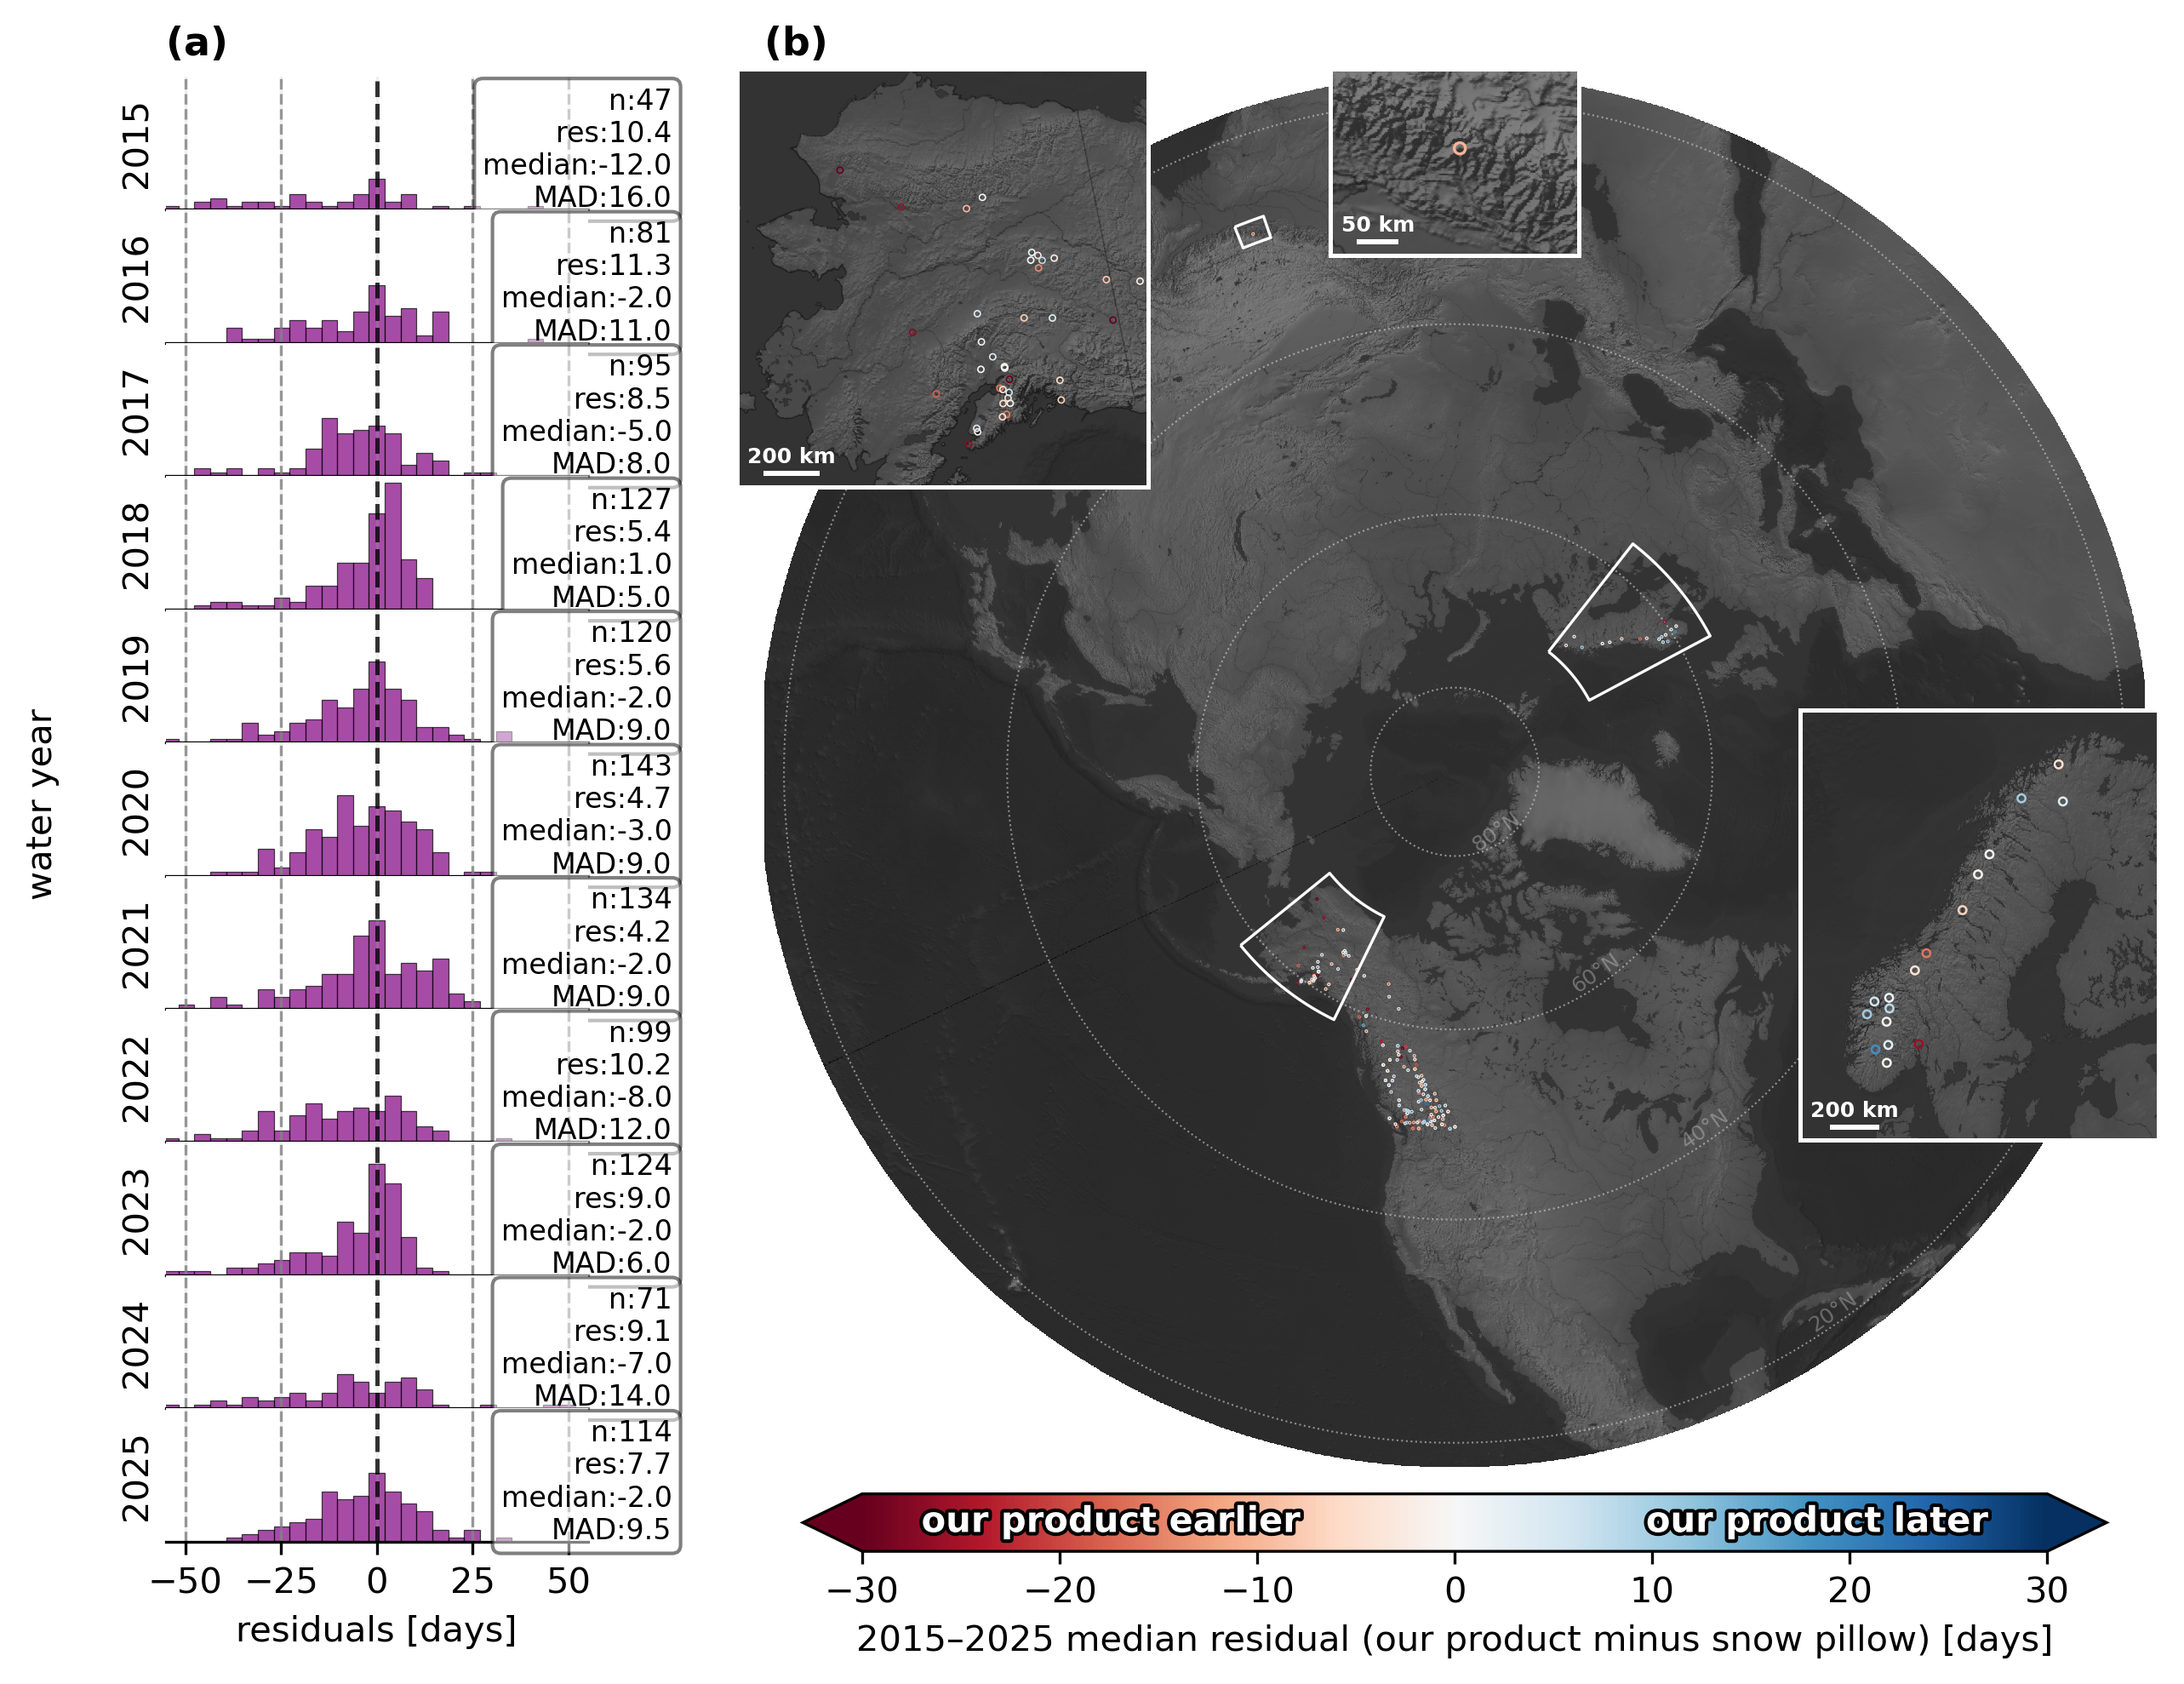

In [17]:
# non-WUS version: Alaska, British Columbia, Norway, and Nepal stations only
# Everything outside the contiguous US, showing the Alaska, Norway, and Nepal insets.
station_bias_gdf_nonWUS = station_bias_gdf[~_wus_bias]
df_residuals_nonWUS     = df_residuals[~_wus_res]
print(f"non-WUS: {station_bias_gdf_nonWUS['station_id'].nunique()} stations, {len(df_residuals_nonWUS)} station-water-years")

make_regional_insets_figure(
    df_residuals_nonWUS,
    station_bias_gdf_nonWUS,
    {k: ALL_REGIONS[k] for k in ['Alaska', 'Norway', 'Nepal']},
    temp_res_for(df_residuals_nonWUS),
    save_suffix='_nonWUS',
)

In [ ]:
# Persist the manuscript-cited evaluation numbers (Abstract / Sect. 4.2 headline
# stats and the Fig. 5 per-water-year annotations) -- their durable home.
from global_snowmelt_runoff_onset.results import save_result_table

def _mad(x):
    return float(np.median(np.abs(x - x.median())))

summary_df = pd.DataFrame([
    {'subset': name,
     'n_stations': df['station_id'].nunique(),
     'n_station_water_years': len(df),
     'median_residual_days': float(df['residual'].median()),
     'mad_residual_days': _mad(df['residual']),
     'mean_temporal_resolution_days': round(float(np.nanmean(temp_res_for(df))), 2)}
    for name, df in [('all', df_residuals),
                     ('WUS', df_residuals_WUS),
                     ('nonWUS', df_residuals_nonWUS)]
])
for k, v in [('fcf_lte', fcf_lte), ('max_swe_gte_mm', max_swe_gte),
             ('temp_res_lte_days', temp_res_lte), ('radius_lte_m', radius_lte),
             ('exclude_worldcover', '_'.join(str(x) for x in exclude_worldcover)),
             ('valid_cnt', valid_cnt), ('swe_pct_threshold', PCT)]:
    summary_df[k] = v
save_result_table(summary_df, 'evaluation_summary', version=VERSION)

tr_per_wy = temp_res_for(df_residuals)
per_wy_df = pd.DataFrame([
    {'water_year': int(wy),
     'n': int((df_residuals['water_year'] == wy).sum()),
     'median_residual_days': (float(sub.median()) if len(sub) else None),
     'mad_residual_days': (_mad(sub) if len(sub) else None),
     'mean_temporal_resolution_days': round(tr, 2)}
    for wy, tr in zip(water_years, tr_per_wy)
    for sub in [df_residuals.loc[df_residuals['water_year'] == wy, 'residual']]
])
save_result_table(per_wy_df, 'evaluation_per_water_year', version=VERSION)
summary_df